In [ ]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [ ]:
# -----------------------------
# Imports
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

# GPU-based RAPIDS modules
import cudf
import cupy as cp
from cuml.preprocessing import StandardScaler
from cuml.linear_model import LogisticRegression as cuLogisticRegression
from cuml.pipeline import Pipeline

In [ ]:
# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("creditcard.csv")
X = df.drop("Class", axis=1)
y = df["Class"]

# -----------------------------
# Global settings
# -----------------------------
TEST_SIZE = 0.2
RANDOM_STATE = 42
KFOLD_SPLITS = 3
CUSTOM_THRESHOLD = 0.3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# =========================================================
# Parameter grid for grid search
# =========================================================
LR_PARAM_GRID = {
    "C": np.logspace(-4, 3, 8),       # Regularization strength range
    "penalty": ["l2"],                # cuML supports only L2
    "fit_intercept": [True, False],
    "tol": [1e-2, 1e-3, 1e-4],        # Convergence tolerance
    "max_iter": [500, 1000, 2000],    # Avoid early stopping
}

# Optional fallback solvers (CPU) if cuML fails
LR_SOLVERS = ["lbfgs", "saga"]

In [ ]:
# =========================================================
# Helper: Convert GPU probability outputs safely
# =========================================================
def _proba_to_numpy_two_cols(proba):
    """
    Converts the predict_proba output to a NumPy array of shape (n, 2),
    handling both cuML (CuPy) and cuDF formats safely.
    """
    if isinstance(proba, cp.ndarray):
        return cp.asnumpy(proba)
    if isinstance(proba, cudf.DataFrame):
        return proba.to_pandas().values
    try:
        return proba.get()
    except Exception:
        pass
    try:
        return np.asarray(proba)
    except Exception:
        raise TypeError("Unsupported predict_proba output type.")

# =========================================================
# Helper: Class balancing strategies
# =========================================================
def _balance_with(method, X_cpu, y_cpu):
    """
    Returns balanced (X, y) based on method:
      - 'none': no balancing
      - 'smote': synthetic minority oversampling
      - 'class_weight': emulate 'balanced' using undersampling
      - 'smote_class_weight': apply SMOTE (CW not natively supported in cuML)
    """
    method = method.lower()
    if method == "none":
        return X_cpu, y_cpu
    if method == "smote":
        sm = SMOTE(random_state=RANDOM_STATE)
        return sm.fit_resample(X_cpu, y_cpu)
    if method == "class_weight":
        rus = RandomUnderSampler(random_state=RANDOM_STATE)
        return rus.fit_resample(X_cpu, y_cpu)
    if method == "smote_class_weight":
        sm = SMOTE(random_state=RANDOM_STATE)
        return sm.fit_resample(X_cpu, y_cpu)
    return X_cpu, y_cpu

# =========================================================
# Build model (GPU or fallback CPU)
# =========================================================
def build_logistic(C=1.0, fit_intercept=True, tol=1e-4, max_iter=1000, solver=None):
    """
    Builds a Logistic Regression pipeline with scaling.
    Uses cuML on GPU, falls back to sklearn on CPU if necessary.
    """
    print(f"Building Logistic Regression: C={C}, tol={tol}, fit_intercept={fit_intercept}, max_iter={max_iter}")
    try:
        return Pipeline([
            ("scaler", StandardScaler(with_mean=True)),
            ("log_reg", cuLogisticRegression(
                C=C,
                penalty="l2",
                max_iter=max_iter,
                fit_intercept=fit_intercept,
                tol=tol
            ))
        ])
    except Exception as e:
        print(f"cuML failed ({e}), falling back to sklearn LogisticRegression (CPU).")
        from sklearn.pipeline import Pipeline as SkPipeline
        from sklearn.preprocessing import StandardScaler as SkScaler
        from sklearn.linear_model import LogisticRegression as SkLogisticRegression

        return SkPipeline([
            ("scaler", SkScaler(with_mean=True)),
            ("log_reg", SkLogisticRegression(
                C=C,
                penalty="l2",
                solver=solver if solver else "lbfgs",
                max_iter=max_iter,
                fit_intercept=fit_intercept,
                tol=tol,
                random_state=RANDOM_STATE
            ))
        ])

# =========================================================
# Cross-validation on GPU
# =========================================================
def cross_validate_gpu(pipeline_builder, X_cpu, y_cpu, kfold):
    """
    Performs K-fold cross-validation using GPU-based model.
    Fits and predicts on GPU, but splits are managed on CPU.
    Returns mean and std of ROC-AUC across folds.
    """
    scores = []
    X_cpu = pd.DataFrame(X_cpu)
    y_cpu = pd.Series(y_cpu)

    for fold, (tr_idx, val_idx) in enumerate(kfold.split(X_cpu, y_cpu), 1):
        Xtr_cpu, Xval_cpu = X_cpu.iloc[tr_idx], X_cpu.iloc[val_idx]
        ytr_cpu, yval_cpu = y_cpu.iloc[tr_idx], y_cpu.iloc[val_idx]

        Xtr_gpu, Xval_gpu = cudf.DataFrame(Xtr_cpu), cudf.DataFrame(Xval_cpu)
        ytr_gpu, yval_gpu = cudf.Series(ytr_cpu), cudf.Series(yval_cpu)

        pipeline = pipeline_builder()
        pipeline.fit(Xtr_gpu, ytr_gpu)

        proba = pipeline.predict_proba(Xval_gpu)
        proba_np = _proba_to_numpy_two_cols(proba)
        y_pred_prob = proba_np[:, 1]

        auc_score = roc_auc_score(yval_cpu.to_numpy(), y_pred_prob)
        print(f"    Fold {fold}: ROC-AUC = {auc_score:.4f}")
        scores.append(auc_score)

    return float(np.mean(scores)), float(np.std(scores))

# =========================================================
# Grid search for best hyperparameters
# =========================================================
def grid_search_logistic(X_cpu, y_cpu, kfold):
    """
    Performs grid search over hyperparameters defined in LR_PARAM_GRID.
    Returns best trained model and its parameter set.
    """
    X_cpu = pd.DataFrame(X_cpu)
    y_cpu = pd.Series(y_cpu)

    best_score, best_params, best_builder = -1, None, None

    print("\n" + "="*60)
    print("GPU LOGISTIC REGRESSION GRID SEARCH STARTED")
    print("="*60 + "\n")

    for C in LR_PARAM_GRID["C"]:
        for fit_int in LR_PARAM_GRID["fit_intercept"]:
            for tol in LR_PARAM_GRID["tol"]:
                for max_iter in LR_PARAM_GRID["max_iter"]:
                    print(f"  Testing C={C}, fit_intercept={fit_int}, tol={tol}, max_iter={max_iter}")

                    builder = (lambda C=C, fit_int=fit_int, tol=tol, max_iter=max_iter:
                               build_logistic(C=C, fit_intercept=fit_int, tol=tol, max_iter=max_iter))

                    mean_auc, std_auc = cross_validate_gpu(builder, X_cpu, y_cpu, kfold)
                    print(f"    CV ROC-AUC: {mean_auc:.4f} ± {std_auc:.4f}\n")

                    if mean_auc > best_score:
                        best_score = mean_auc
                        best_params = {"C": C, "fit_intercept": fit_int, "tol": tol, "max_iter": max_iter}
                        best_builder = builder

    print(f"\nBest Params: {best_params}, ROC-AUC={best_score:.4f}")

    final_model = best_builder()
    final_model.fit(cudf.DataFrame(X_cpu), cudf.Series(y_cpu))
    return final_model, best_params

# =========================================================
# Evaluation
# =========================================================
def evaluate_gpu(model, X_test, y_test, label="Model", threshold=0.3):
    """
    Evaluates trained model and generates metrics and diagnostic plots.
    Works for both cuML and sklearn models.
    """
    try:
        proba = model.predict_proba(X_test)
        proba_np = _proba_to_numpy_two_cols(proba)
        y_prob = proba_np[:, 1]
    except Exception:
        y_prob = model.decision_function(X_test)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-9)

    y_test = np.array(y_test)
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec, prec)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
    best_idx = np.argmax(f1)
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else threshold

    print(f"\n{label} — Evaluation Metrics")
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print(f"PR-AUC Score:  {pr_auc:.4f}")
    print(f"Optimal Threshold (by F1): {best_thresh:.3f}  (F1 = {np.max(f1):.3f})")

    # Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix — {label}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Precision–Recall Curve
    plt.figure(figsize=(6, 5))
    plt.plot(rec, prec, lw=2, color="orange", label=f"PR-AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # F1 vs Threshold
    plt.figure(figsize=(6, 5))
    plt.plot(thresholds, f1[:-1], lw=2, color="purple")
    plt.xlabel("Threshold")
    plt.ylabel("F1-score")
    plt.title(f"F1 vs Threshold — {label}")
    plt.tight_layout()
    plt.show()

    return {
        "model": label,
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "best_threshold": float(best_thresh),
        "confusion_matrix": cm,
        "classification_report": classification_report(
            y_test, y_pred, digits=4, output_dict=True
        ),
        "best_params": None  # Placeholder, filled later
    }

# =========================================================
# Training wrapper
# =========================================================
def train_logistic_gpu(X_train, y_train, X_test, y_test,
                       custom_threshold=0.3, balance_method="none"):
    """
    Trains Logistic Regression on GPU for a given balancing method.
    Performs grid search, evaluates, and returns best model, parameters, metrics.
    """
    print("==============================================")
    print(f"GPU LOGISTIC REGRESSION TRAINING STARTED ({balance_method.upper()})")
    print("==============================================")

    X_bal, y_bal = _balance_with(balance_method, pd.DataFrame(X_train), pd.Series(y_train))

    kfold = StratifiedKFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    best_model, best_params = grid_search_logistic(X_bal, y_bal, kfold)

    print(f"Best Parameters: {best_params}")
    print("\nEvaluating on Test Set...")

    metrics = evaluate_gpu(best_model, X_test, y_test,
                           label=f"Logistic Regression ({balance_method.upper()})",
                           threshold=custom_threshold)
    metrics["best_params"] = best_params
    return best_model, best_params, metrics


GPU LOGISTIC REGRESSION TRAINING STARTED (NONE)

GPU LOGISTIC REGRESSION GRID SEARCH STARTED

  Testing C=0.0001, fit_intercept=True, tol=0.01, max_iter=500
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=500
    Fold 1: ROC-AUC = 0.9789
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=500
    Fold 2: ROC-AUC = 0.9717
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=500
    Fold 3: ROC-AUC = 0.9821
    CV ROC-AUC: 0.9776 ± 0.0043

  Testing C=0.0001, fit_intercept=True, tol=0.01, max_iter=1000
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=1000
    Fold 1: ROC-AUC = 0.9789
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=1000
    Fold 2: ROC-AUC = 0.9717
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=1000
    Fold 3: ROC-AUC = 0.9821
    CV ROC-AUC: 0.9776 ± 0.0043

  Testing C=0.0001, fit_intercept=True

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


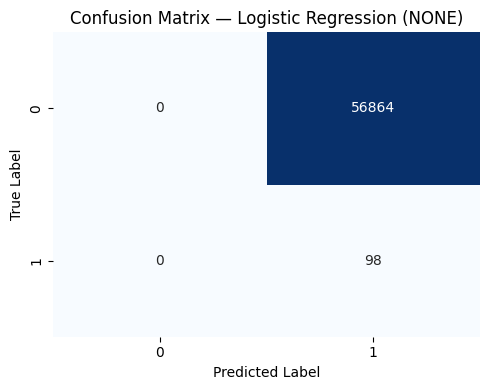

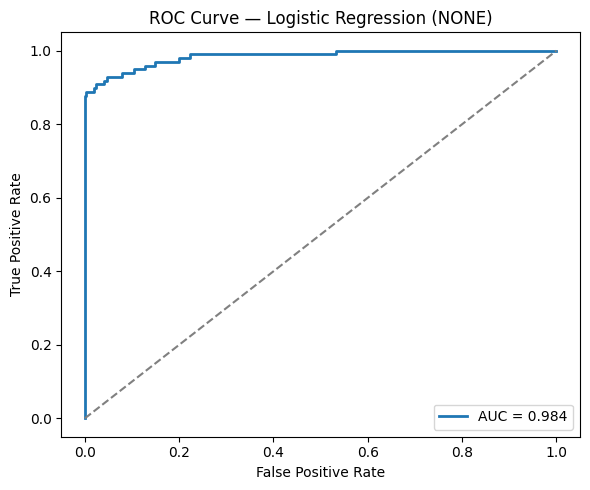

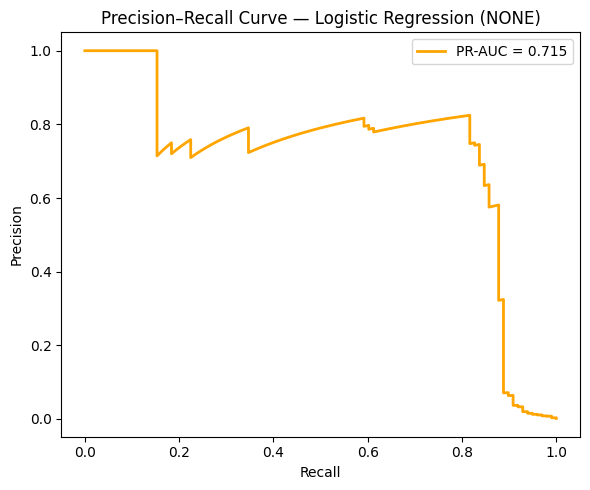

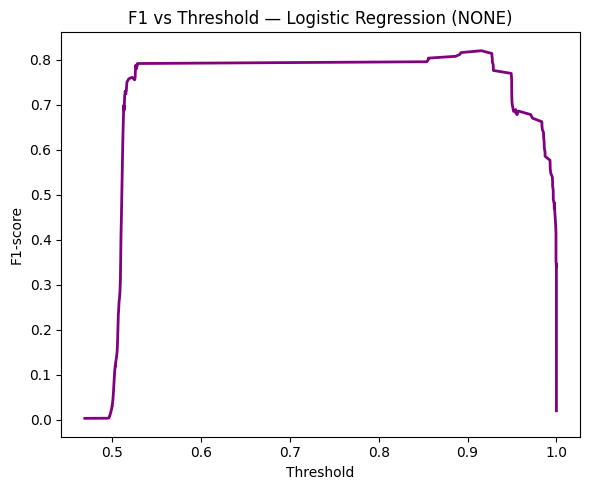

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ================================================
# 🔹 RUN 1 — NO BALANCING
# ================================================
lr_none_model,  lr_none_params,  lr_none_metrics  = train_logistic_gpu(
    X_train, y_train, X_test, y_test,
    balance_method="none", custom_threshold=0.3
)


GPU LOGISTIC REGRESSION TRAINING STARTED (CLASS_WEIGHT)

GPU LOGISTIC REGRESSION GRID SEARCH STARTED

  Testing C=0.0001, fit_intercept=True, tol=0.01, max_iter=500
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=500
    Fold 1: ROC-AUC = 0.9367
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=500
    Fold 2: ROC-AUC = 0.9542
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=500
    Fold 3: ROC-AUC = 0.9538
    CV ROC-AUC: 0.9483 ± 0.0082

  Testing C=0.0001, fit_intercept=True, tol=0.01, max_iter=1000
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=1000
    Fold 1: ROC-AUC = 0.9367
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=1000
    Fold 2: ROC-AUC = 0.9542
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=1000
    Fold 3: ROC-AUC = 0.9538
    CV ROC-AUC: 0.9483 ± 0.0082

  Testing C=0.0001, fit_interc

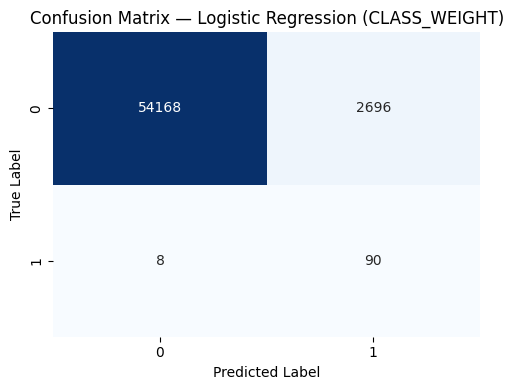

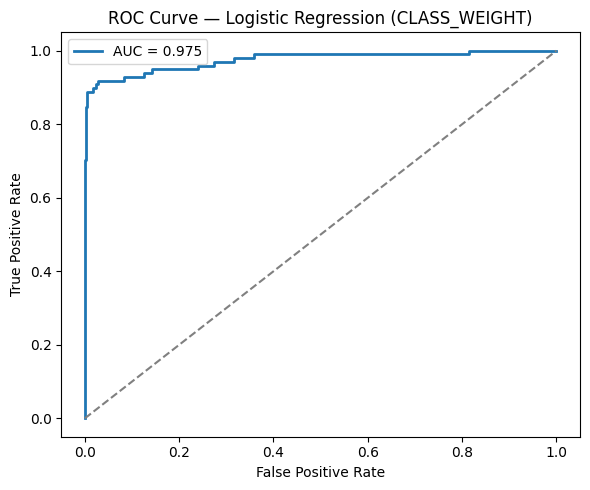

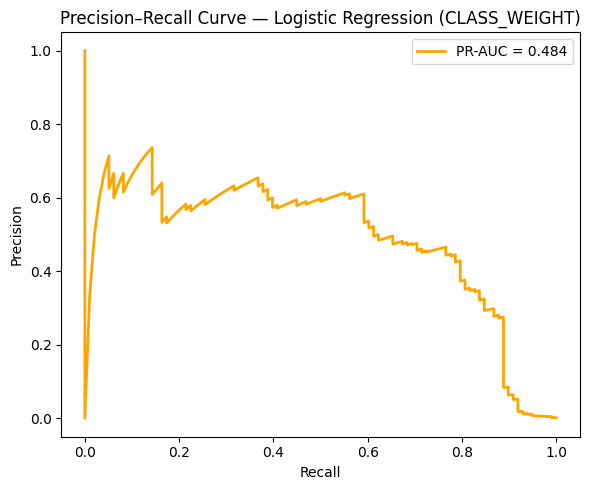

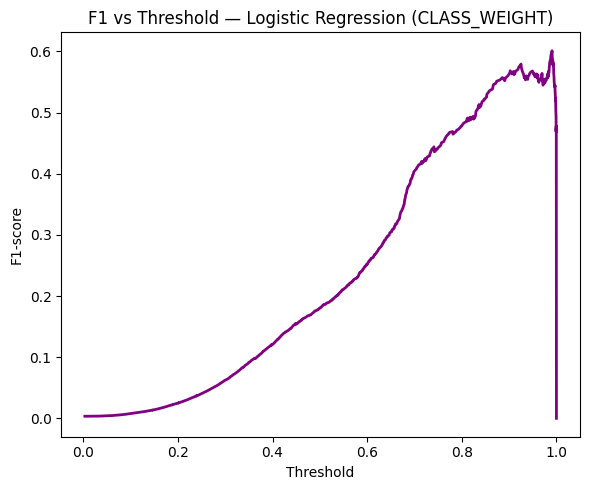

In [ ]:
# ================================================
# 🔹 RUN 2 — CLASS WEIGHT
# ================================================
lr_cw_model,    lr_cw_params,    lr_cw_metrics    = train_logistic_gpu(
    X_train, y_train, X_test, y_test,
    balance_method="class_weight", custom_threshold=0.3
)


GPU LOGISTIC REGRESSION TRAINING STARTED (SMOTE)

GPU LOGISTIC REGRESSION GRID SEARCH STARTED

  Testing C=0.0001, fit_intercept=True, tol=0.01, max_iter=500
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=500
    Fold 1: ROC-AUC = 0.9951
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=500
    Fold 2: ROC-AUC = 0.9949
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=500
    Fold 3: ROC-AUC = 0.9945
    CV ROC-AUC: 0.9948 ± 0.0002

  Testing C=0.0001, fit_intercept=True, tol=0.01, max_iter=1000
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=1000
    Fold 1: ROC-AUC = 0.9951
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=1000
    Fold 2: ROC-AUC = 0.9949
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=1000
    Fold 3: ROC-AUC = 0.9945
    CV ROC-AUC: 0.9948 ± 0.0002

  Testing C=0.0001, fit_intercept=Tru

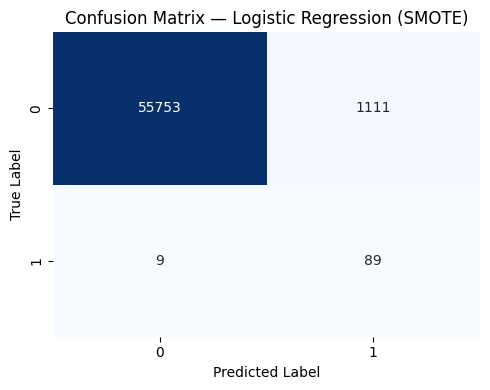

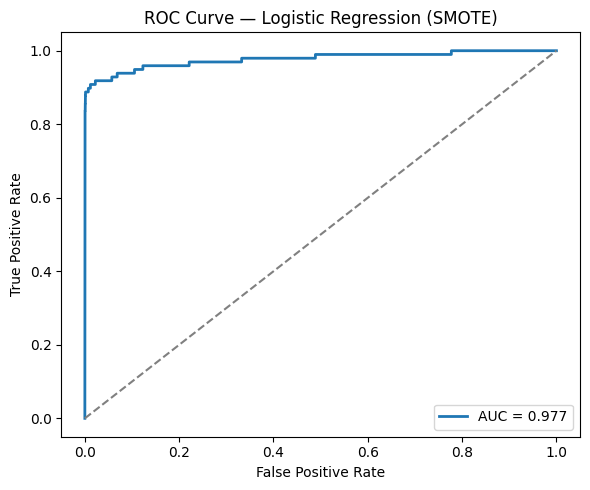

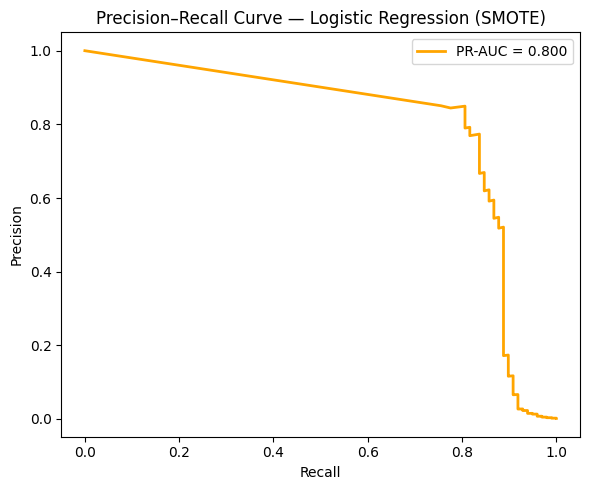

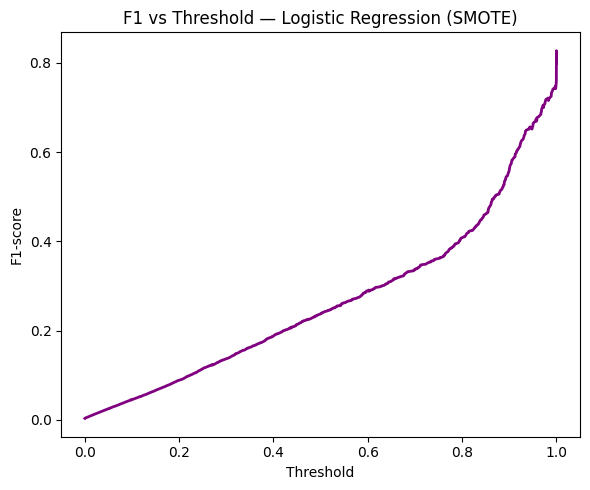

In [ ]:
# ================================================
# 🔹 RUN 3 — SMOTE
# ================================================
lr_smote_model, lr_smote_params, lr_smote_metrics = train_logistic_gpu(
    X_train, y_train, X_test, y_test,
    balance_method="smote", custom_threshold=0.3
)

GPU LOGISTIC REGRESSION TRAINING STARTED (SMOTE_CLASS_WEIGHT)

GPU LOGISTIC REGRESSION GRID SEARCH STARTED

  Testing C=0.0001, fit_intercept=True, tol=0.01, max_iter=500
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=500
    Fold 1: ROC-AUC = 0.9951
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=500
    Fold 2: ROC-AUC = 0.9949
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=500
    Fold 3: ROC-AUC = 0.9945
    CV ROC-AUC: 0.9948 ± 0.0002

  Testing C=0.0001, fit_intercept=True, tol=0.01, max_iter=1000
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=1000
    Fold 1: ROC-AUC = 0.9951
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=1000
    Fold 2: ROC-AUC = 0.9949
Building Logistic Regression: C=0.0001, tol=0.01, fit_intercept=True, max_iter=1000
    Fold 3: ROC-AUC = 0.9945
    CV ROC-AUC: 0.9948 ± 0.0002

  Testing C=0.0001, fit_

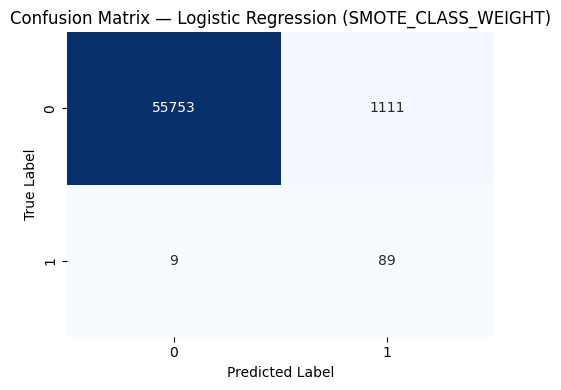

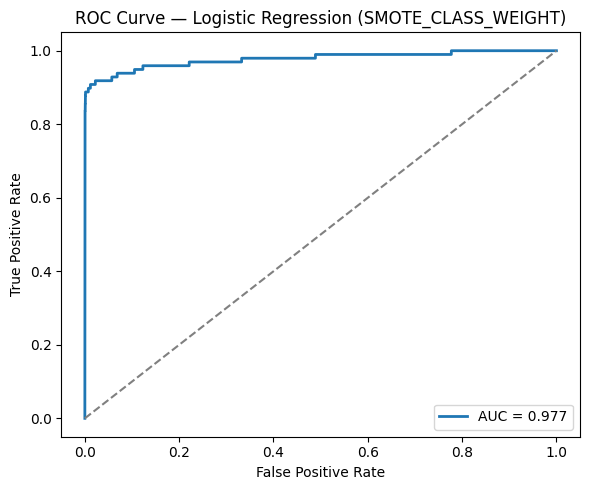

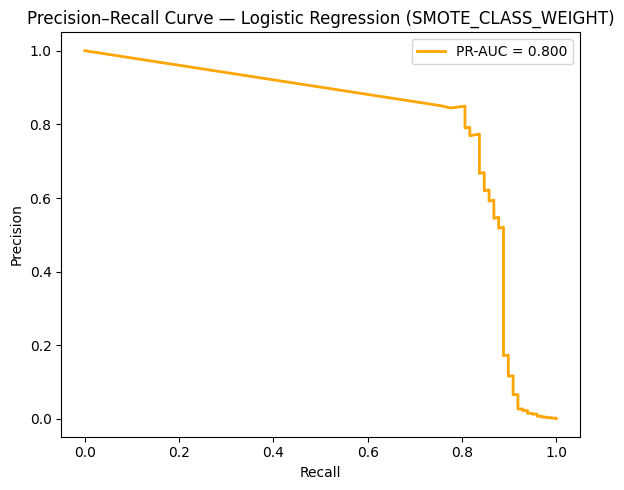

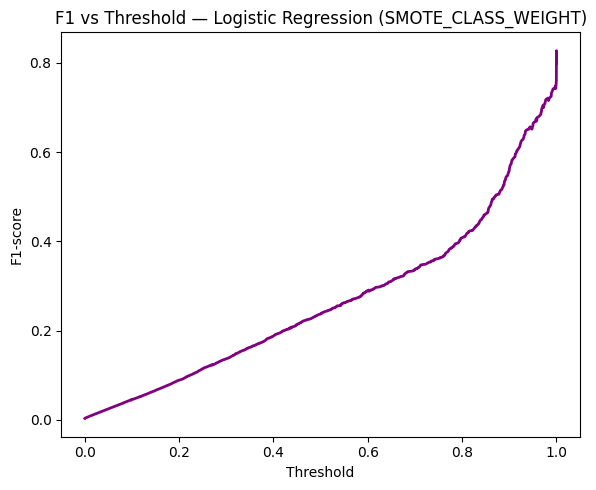

In [ ]:
# ================================================
# 🔹 RUN 4 — SMOTE + CLASS_WEIGHT
# ================================================
lr_hybrid_model, lr_hybrid_params, lr_hybrid_metrics = train_logistic_gpu(
    X_train, y_train, X_test, y_test,
    balance_method="smote_class_weight", custom_threshold=0.3
)

In [ ]:
# =========================================================
# Results summary
# =========================================================
results_df = pd.DataFrame([
    {"Model": "LR — None", "ROC-AUC": lr_none_metrics["roc_auc"], "PR-AUC": lr_none_metrics["pr_auc"], "Best Params": lr_none_metrics["best_params"]},
    {"Model": "LR — Class Weight (RUS)", "ROC-AUC": lr_cw_metrics["roc_auc"], "PR-AUC": lr_cw_metrics["pr_auc"], "Best Params": lr_cw_metrics["best_params"]},
    {"Model": "LR — SMOTE", "ROC-AUC": lr_smote_metrics["roc_auc"], "PR-AUC": lr_smote_metrics["pr_auc"], "Best Params": lr_smote_metrics["best_params"]},
    {"Model": "LR — SMOTE + CW", "ROC-AUC": lr_hybrid_metrics["roc_auc"], "PR-AUC": lr_hybrid_metrics["pr_auc"], "Best Params": lr_hybrid_metrics["best_params"]}
])

print("\n================== GPU LOGISTIC REGRESSION RESULTS ==================")
print(results_df.to_string(index=False))


================== GPU LOGISTIC REGRESSION RESULTS ==================
                  Model  ROC-AUC   PR-AUC                                                          Best Params
              LR — None 0.984004 0.715209 {'C': 0.0001, 'fit_intercept': False, 'tol': 0.001, 'max_iter': 500}
LR — Class Weight (RUS) 0.974520 0.483720    {'C': 0.1, 'fit_intercept': True, 'tol': 0.0001, 'max_iter': 500}
             LR — SMOTE 0.977230 0.800416   {'C': 100.0, 'fit_intercept': True, 'tol': 0.001, 'max_iter': 500}
        LR — SMOTE + CW 0.977230 0.800416   {'C': 100.0, 'fit_intercept': True, 'tol': 0.001, 'max_iter': 500}
